# 12. Curl and the Endless Loop: Fields in Motion

Chapter 10's wind had a flaw you could see: particles piled up in channels and blew out of the frame, and every run was a one-way journey. Today we fix both, with one quarter turn of mathematics: flow that never pools, and then, with one more trick, time that never ends.

## Today's destination

Two artworks, one still and one moving. The still: a long exposure of thousands of particles riding a curl field, closed currents swirling in glacier light, the whole frame evenly alive because this flow *cannot* abandon a region or flood one. The moving: an animated loop of the field itself, breathing, whose last frame is its first frame, so it circles forever without a visible seam, the oldest form of moving image reborn as a GIF. Both come from the same idea: do not use noise as a velocity, use it as a *potential*, and let the velocity be its curl.

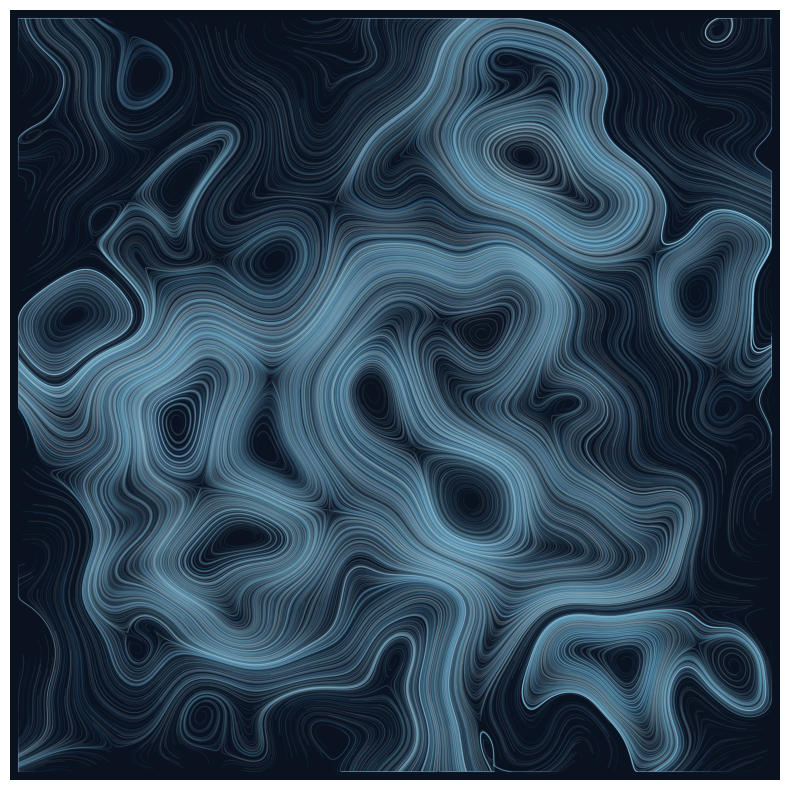

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch12_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: smoke for the movies, and the wheel of life

The fix for pooling particles has an exact address: Robert Bridson, Jim Hourihan and Marcus Nordenstam, "Curl-Noise for Procedural Fluid Flow", SIGGRAPH 2007, four pages written for film-effects artists who needed smoke and ink that swirl convincingly without running a physics simulation. Their diagnosis of naive noise-driven motion is our chapter 10 exactly: such fields "contain many sinks ('gutters' where particles accumulate)" <a class="cite" href="#ref-bridson2007">(Bridson et al. 2007)</a>, their word for the bright channels of our ember showpiece. Their cure is a classic vector-calculus identity: the curl of a potential field is automatically divergence-free, no sources, no sinks, no gutters possible, and film pipelines have breathed with it ever since. It is also, once more, the marbler's chapter: a comb dragged through the bath pushes pigment aside and the bath closes behind it, because the liquid is incompressible; chapter 11 borrowed marbling's *look* by warping space, and today we borrow its *physics*.

The loop's lineage is older than cinema. In the winter of 1832-33, the Belgian physicist **Joseph Plateau** and the Austrian **Simon Stampfer** independently built the same toy: a spinning disc of sequential drawings viewed through slits, the phenakistiscope, the first widely sold device to make drawings *move* <a class="cite" href="#ref-mannoni2000">(Mannoni 2000)</a>. William George Horner bent the disc into a drum in 1834 <a class="cite" href="#ref-horner1834">(Horner 1834)</a>, and in 1865 the eighteen-year-old **William E. Lincoln** perfected that drum as the zoetrope, the "wheel of life", licensed to the game maker Milton Bradley <a class="cite" href="#ref-lincoln1867">(Lincoln 1867)</a>. Notice what all these machines have in common, forced on them by their circular geometry: **the last drawing must lead back into the first.** On a spinning disc or drum the moving image was *necessarily* a seamless loop; open-ended time arrived with the filmstrip. When the GIF (born 1987 at CompuServe, looping since a Netscape extension of 1995; <a class="cite" href="#ref-eppink2014">Eppink 2014</a>) became the web's folk format for short repeating animations, the zoetrope's constraint returned as an aesthetic: the good GIF, like the good zoetrope strip, hides its seam. Today's second artwork honors that hundred-and-ninety-year-old discipline with a mathematical guarantee: frame $N$ will not just resemble frame 0, it will *equal* it.

## The gradient, at last

We have skirted this tool for eleven chapters; it becomes ours today. For a field of values $\psi$ (a grid, in our world), the **gradient** asks at every point: *which way is uphill, and how steep?* On a grid the answer is a difference of neighbors. NumPy's `np.gradient` uses the **central difference**: the slope at cell $i$ is the neighbor ahead minus the neighbor behind, divided by the two steps between them,

$$\text{slope}_i \approx \frac{\psi_{i+1} - \psi_{i-1}}{2}.$$

Feed it a 2D grid and it returns *two* grids: the slope along the rows and the slope along the columns, together a little arrow $\nabla\psi$ at every cell pointing uphill. The three-line example below is worth running slowly; every use of `np.gradient` from here to chapter 27 is this example at scale.

In [2]:
# np.gradient in miniature: five values, slopes you can check by eye
import numpy as np

heights = np.array([0.0, 1.0, 4.0, 9.0, 16.0])     # a parabola, sampled
slopes = np.gradient(heights)
for h, s in zip(heights, slopes):
    print(f"height {h:5.1f}   slope {s:5.1f}")
print()
print("interior slopes are (next - previous) / 2; the two ends use their")
print("single available neighbor, which is why 1.0 and 7.0 break the pattern")

height   0.0   slope   1.0
height   1.0   slope   2.0
height   4.0   slope   4.0
height   9.0   slope   6.0
height  16.0   slope   7.0

interior slopes are (next - previous) / 2; the two ends use their
single available neighbor, which is why 1.0 and 7.0 break the pattern


Now the same on a real field. We rebuild chapter 10's fbm in three condensed lines (octaves of `noise2array`, stacked with halving amplitudes; that chapter has the slow story) and ask for its gradient. One care with directions, worth a comment in every notebook you ever write: for an image-like grid, `np.gradient` returns the slopes in *row* order first, and rows are the y-axis, so the pair arrives as $(\partial\psi/\partial y, \partial\psi/\partial x)$.

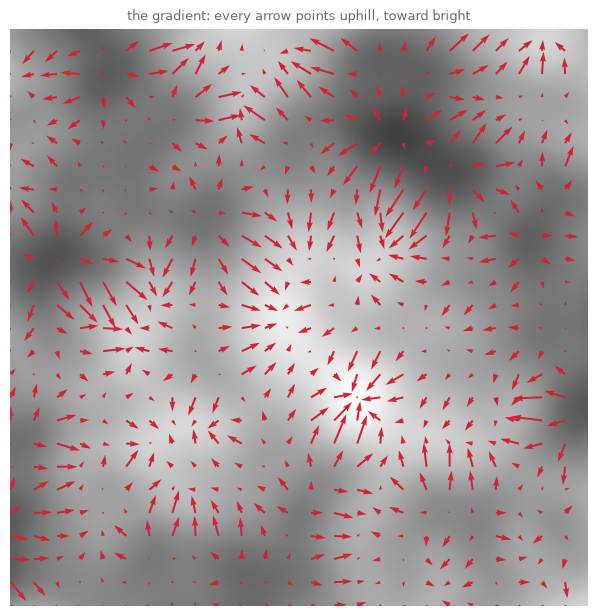

In [3]:
# a potential field and its uphill arrows
import sys
import opensimplex

sys.path.append("..")                       # make the course package importable
from agap.helpers import PAPER, PALETTES, save_artwork

def fbm(xs, ys, octaves=3, persistence=0.5, lacunarity=2.0):
    # chapter 10's octave_noise, condensed
    total = np.zeros((len(ys), len(xs)))
    amplitude, frequency = 1.0, 1.0
    for _ in range(octaves):
        total += amplitude * opensimplex.noise2array(xs * frequency, ys * frequency)
        amplitude *= persistence
        frequency *= lacunarity
    return total / np.max(np.abs(total))

GRID = 400
axis = np.linspace(0, 2.5, GRID)
opensimplex.seed(11)
psi = fbm(axis, axis)                       # the potential (Potentialfeld)
dpsi_dy, dpsi_dx = np.gradient(psi)         # row-slopes first: y, then x

coarse = slice(None, None, 16)              # every 16th cell: readable arrows
xx, yy = np.meshgrid(np.arange(GRID), np.arange(GRID))
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(psi, cmap="gray", origin="lower", alpha=0.75)
ax.quiver(xx[coarse, coarse], yy[coarse, coarse],
          dpsi_dx[coarse, coarse], dpsi_dy[coarse, coarse],
          color="#D02433", width=0.0035)
ax.set_title("the gradient: every arrow points uphill, toward bright",
             fontsize=9, color="#6B6B6B")
ax.axis("off")
plt.show()

Arrows climb toward the bright hills and flee the dark basins; where the field is flat, they shrink to dots. A particle *following* these arrows would run uphill, gather at the summits, and stop: the gradient makes sinks by design. (Chapter 15 will point such arrows at image edges to place mosaic seeds; you will already own the machinery when it does.)

## The quarter turn

Here is the whole trick of the Bridson paper, in one move a compass can perform. **Rotate every arrow a quarter turn.** A rotated arrow no longer climbs the hill; it walks *around* it, along the contour line it stands on. In coordinates, turning $(\partial\psi/\partial x, \partial\psi/\partial y)$ by 90 degrees gives the **curl field** (in 2D, the curl of the scalar potential):

$$v \;=\; \Big(\frac{\partial \psi}{\partial y},\; -\frac{\partial \psi}{\partial x}\Big),$$

read aloud: *swap the two slopes and negate one.* Why this cannot pool is best said visually, and the figure below says it: the velocity is everywhere parallel to the contour lines of $\psi$, so every particle is condemned to orbit its own level set, around and around, like a skater on a closed rink. Piling up would require *crossing* contours, and the field never points that way. (The formal statement is that this field's divergence is zero, "divergence-free" (quellenfrei); the picture is the proof we will trust.)

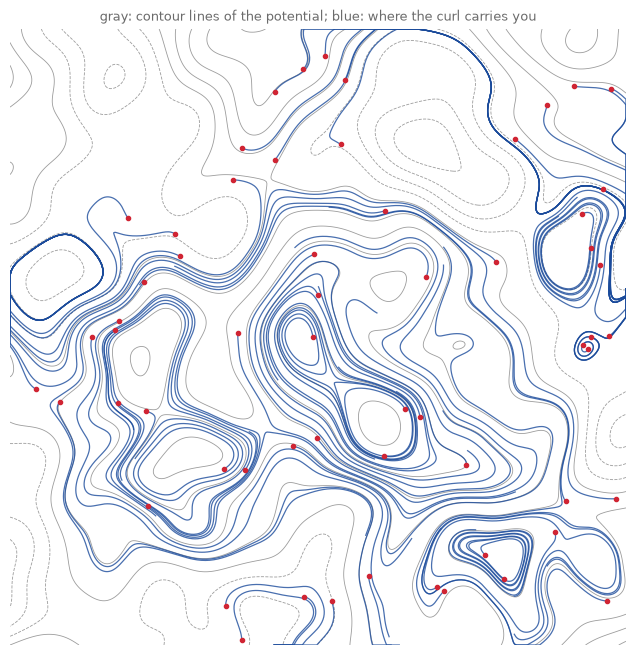

In [4]:
# THE figure: contours of the potential, and particles riding the curl
from scipy.ndimage import map_coordinates

curl_x, curl_y = dpsi_dy, -dpsi_dx          # the quarter turn, verbatim

def ride(vx_grid, vy_grid, x, y, steps, dt=0.9, unit_speed=True):
    """Advect points through a velocity grid; positions in pixel units.
    Velocities between pixels come from chapter 11's between-the-pixels
    reader, map_coordinates."""
    path_x, path_y = [x.copy()], [y.copy()]
    for _ in range(steps):
        ux = map_coordinates(vx_grid, [y, x], order=1, mode="nearest")
        uy = map_coordinates(vy_grid, [y, x], order=1, mode="nearest")
        if unit_speed:                       # keep everyone moving equally fast
            norm = np.hypot(ux, uy)
            norm[norm < 1e-9] = 1e-9
            ux, uy = ux / norm, uy / norm
        x = np.clip(x + dt * ux, 0, GRID - 1)
        y = np.clip(y + dt * uy, 0, GRID - 1)
        path_x.append(x.copy())
        path_y.append(y.copy())
    return np.array(path_x), np.array(path_y)

rng = np.random.default_rng(4)
start_x = rng.random(60) * (GRID - 1)
start_y = rng.random(60) * (GRID - 1)
paths_x, paths_y = ride(curl_x, curl_y, start_x, start_y, steps=500)

fig, ax = plt.subplots(figsize=(8, 8))
ax.contour(psi, levels=14, colors="#9C9C9C", linewidths=0.6)
ax.plot(paths_x, paths_y, color="#1B4B9B", lw=0.9, alpha=0.8)
ax.plot(start_x, start_y, "o", color="#D02433", markersize=3)
ax.set_aspect("equal")
ax.set_title("gray: contour lines of the potential; blue: where the curl carries you",
             fontsize=9, color="#6B6B6B")
ax.axis("off")
plt.show()

**Look and compare.** The blue trajectories trace the gray contours: sixty particles dropped at random (red dots), and each one settles into circling whatever level set it landed on. Some rinks are small and busy, some are lazy province-sized loops, and none of them ends anywhere.

## The empirical proof: clumps vs evenness

Chapter 10's field turned noise directly into an *angle*; today's turns it into a potential and takes the curl. Same noise, two philosophies. Let us give both the same thirty thousand particles, the same three hundred steps, and count heads per cell afterwards with chapter 9's census.

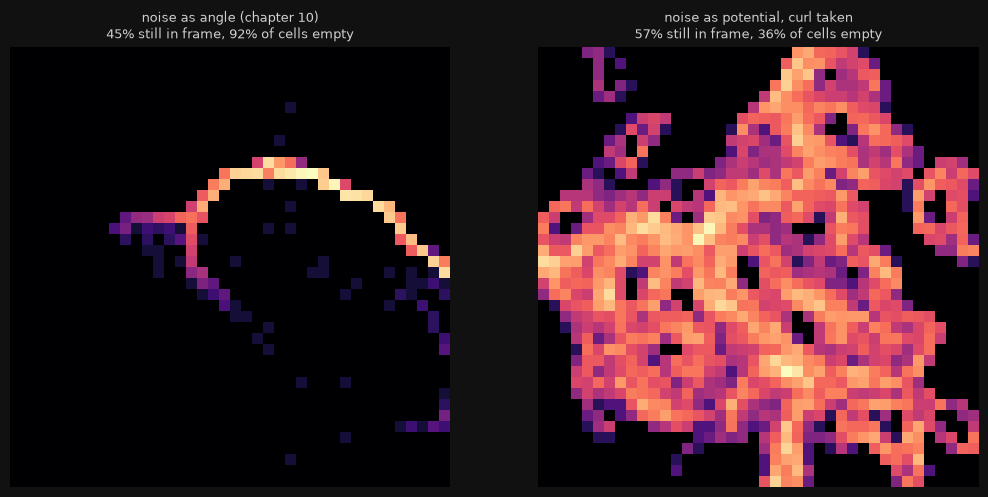

In [5]:
# one potential, two flows: where is everybody after 300 steps?
def survivors(vx_grid, vy_grid, n=30_000, steps=300, seed=5):
    rng = np.random.default_rng(seed)
    x = rng.random(n) * (GRID - 1)
    y = rng.random(n) * (GRID - 1)
    alive = np.ones(n, dtype=bool)
    for _ in range(steps):
        ux = map_coordinates(vx_grid, [y, x], order=1, mode="nearest")
        uy = map_coordinates(vy_grid, [y, x], order=1, mode="nearest")
        norm = np.hypot(ux, uy)
        norm[norm < 1e-9] = 1e-9
        x = x + 0.9 * ux / norm
        y = y + 0.9 * uy / norm
        alive &= (x >= 0) & (x <= GRID - 1) & (y >= 0) & (y <= GRID - 1)
        x = np.clip(x, 0, GRID - 1)
        y = np.clip(y, 0, GRID - 1)
    return x[alive], y[alive], alive.mean()

angle = psi * np.pi                          # chapter 10's move: noise as angle
angle_x, angle_y = np.cos(angle), np.sin(angle)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8), facecolor="#111111")
for ax, (vx_grid, vy_grid, label) in zip(axes, [
        (angle_x, angle_y, "noise as angle (chapter 10)"),
        (curl_x, curl_y, "noise as potential, curl taken")]):
    x, y, stayed = survivors(vx_grid, vy_grid)
    census, _, _ = np.histogram2d(x, y, bins=40,
                                  range=[[0, GRID - 1], [0, GRID - 1]])
    empty = (census == 0).mean()
    ax.imshow(np.log1p(census).T, origin="lower", cmap="magma")
    ax.set_title(f"{label}\n{stayed:.0%} still in frame, {empty:.0%} of cells empty",
                 fontsize=9, color="#CFCFCF")
    ax.axis("off")
plt.show()

**Look and compare.** This is the chapter's argument in one census. Left, the angle field: more than half the particles have been blown out of the frame, and the rest have collapsed into a single incandescent channel, Bridson's "gutter", with over nine in ten cells standing empty. Right, the curl field: a clear majority is still here, still circulating (the leavers rode contour loops that the frame's edge cuts open), and the stayers spread across the whole territory of swirls. Neither picture is *wrong*, chapter 10's gutters made handsome art, but they are different instruments: the angle field is weather that carries things away, the curl field is a sealed aquarium.

**Try it.** Raise `steps` to 900 and rerun: the left panel empties almost completely, the right keeps circulating. Time is on the curl field's side; that fact becomes the whole last act of this chapter.

## The long exposure, without gutters

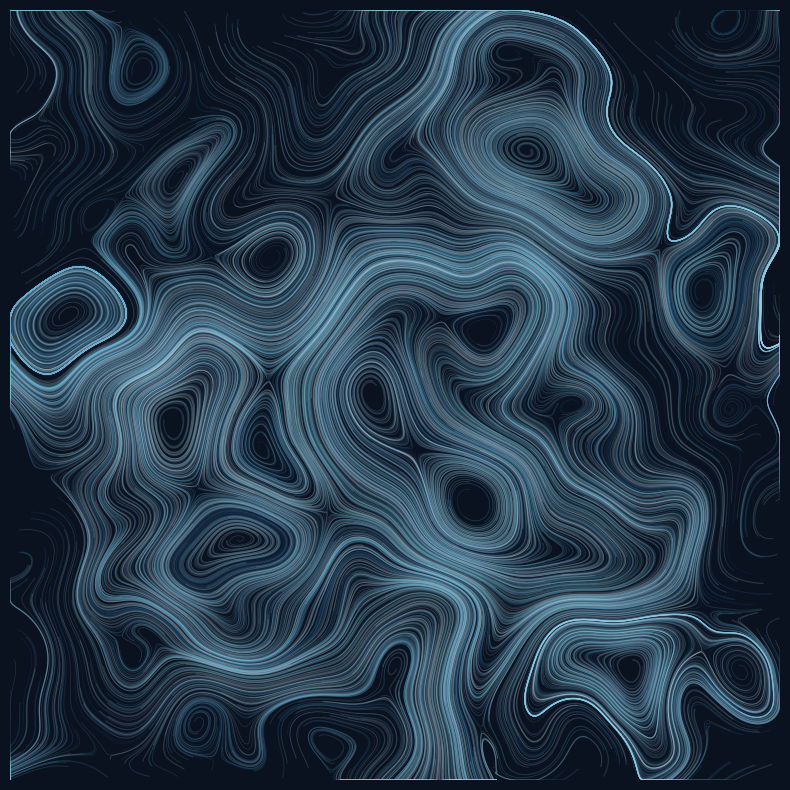

In [6]:
# the still artwork: thousands of skaters, glacier light on deep water
GLACIER = ["#7FD4E6", "#4FA3D1", "#2E6FA3", "#BFE8F2", "#EAF6FF"]

n_skaters = 2600
rng = np.random.default_rng(9)
sk_x = rng.random(n_skaters) * (GRID - 1)
sk_y = rng.random(n_skaters) * (GRID - 1)
trail_x, trail_y = ride(curl_x, curl_y, sk_x, sk_y, steps=420)

from matplotlib.collections import LineCollection
trails = np.stack([trail_x.T, trail_y.T], axis=-1)
colors = [GLACIER[i % len(GLACIER)] for i in range(n_skaters)]
widths = rng.uniform(0.3, 1.0, n_skaters)

fig, ax = plt.subplots(figsize=(10, 10), facecolor="#0A1220")
ax.add_collection(LineCollection(trails, colors=colors, linewidths=widths,
                                 alpha=0.16))
ax.set_facecolor("#0A1220")
ax.set_xlim(0, GRID - 1)
ax.set_ylim(0, GRID - 1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

**Look and compare** this against chapter 10's ember showpiece, its closest relative in the book. There, currents converged into a few blazing rivers with dark banks: gutters, glorified. Here the frame is evenly inhabited from corner to corner, and every current is *closed*: follow any bright loop and it returns. Same particle-tracing machinery, one quarter turn apart. (The palette pulls its weight in the differentiation too: ember heat for the one-way wind, glacier cold for the sealed rink.)

## Time as a circle

Now the loop. A field that *moves* needs noise that varies with time: give `noise` a third coordinate and slide along it, and the field evolves. But slide along a *line* and the animation, like chapter 10's wind, is a one-way journey: frame 300 resembles frame 0 not at all, and the GIF jumps at the wraparound. The zoetrope's discipline demands something better, and the fix is one of the loveliest ideas in the generative folk canon <a class="cite" href="#ref-jacob2017">(Jacob 2017)</a>: **walk a circle, not a line.** Take *four*-dimensional noise and evaluate it at

$$\text{field}(x, y, \theta) = \text{noise}\big(x,\; y,\; R\cos\theta,\; R\sin\theta\big),$$

sweeping $\theta$ from 0 to $2\pi$ across the frames. The two extra coordinates trace a closed circle of radius $R$ through noise space, so frame $N$ *is* frame 0, exactly, and the seam does not exist. (Why four dimensions and not three: the animated *image* already spends two, and a closed circle always needs two of its own.) The radius $R$ is a wonderful dial: how far the circle strays from home is how *much* the field changes mid-loop, so small $R$ breathes and large $R$ churns, and either way it comes home.

One export tool, new today and used for every animation this book makes from here on: **`imageio`**, whose `mimsave` writes a stack of frames as an animated GIF, the web's folk format for exactly this kind of short, seamless, endlessly repeating sketch. `fps` sets the tempo and `loop=0` means "forever", which after nearly two centuries of spinning discs feels like the only honest setting. (This is the notebook's slowest cell, about 45 seconds: 48 separate field evaluations.)

48 frames, 0.52 MB


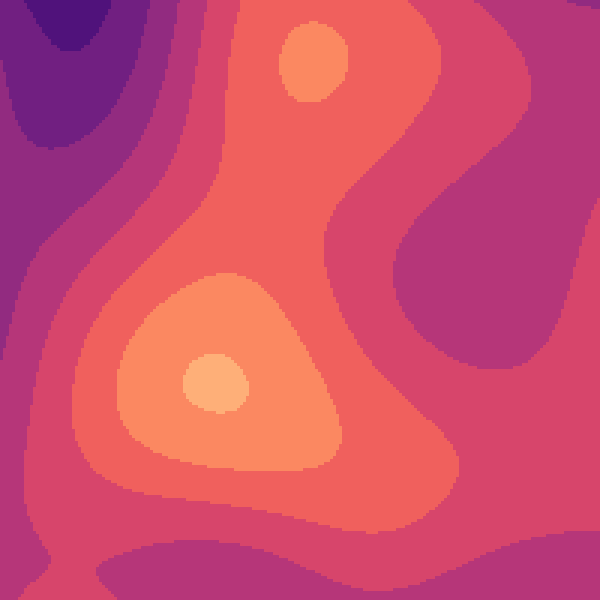

In [7]:
# the endless loop: frames around a circle in noise space, as a function
import imageio.v2 as imageio
from IPython.display import Image as GifImage
import matplotlib.cm as cm

def noise_loop(radius=0.6, frames=48, grid=200,
               path="../assets/outputs/ch12_loop.gif"):
    opensimplex.seed(31)
    loop_axis = np.linspace(0, 2.2, grid)
    thetas = np.linspace(0, 2 * np.pi, frames, endpoint=False)  # last -> first
    gif_frames = []
    for theta in thetas:
        field = opensimplex.noise4array(loop_axis, loop_axis,
                                        np.array([radius * np.cos(theta)]),
                                        np.array([radius * np.sin(theta)]))[0, 0]
        brightness = np.round((field + 1) / 2 * 12) / 12    # 13 levels: small file
        rgb = (cm.magma(brightness)[:, :, :3] * 255).astype(np.uint8)
        # np.kron: enlarge every pixel to a 3x3 block (chapter 13 makes
        # friends with it properly)
        gif_frames.append(np.kron(rgb, np.ones((3, 3, 1))).astype(np.uint8))
    imageio.mimsave(path, gif_frames, fps=16, loop=0)
    print(f"{frames} frames, {os.path.getsize(path) / 1e6:.2f} MB")
    return path

gif_path = noise_loop(radius=0.6)
GifImage(filename=gif_path)

Watch it for a few cycles (it costs nothing; it will run all day) and try to find the seam. There is none to find: the restart is not *hidden*, it is *absent*, the way a circle has no corner. This one runs at radius 0.6, a calm breather.

## Parameter studies: the breath and the churn

A GIF per parameter setting would bloat the page, so we study the loop the way a zoetrope maker would, by laying strips of frames side by side: three moments (start, quarter turn, half turn) for a small radius and a large one.

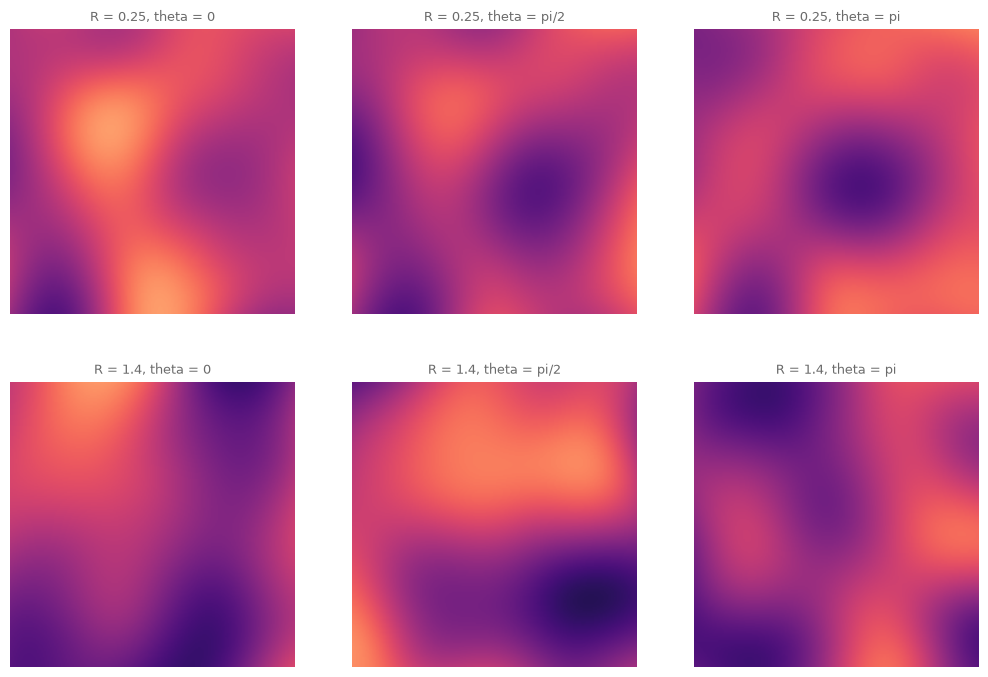

In [8]:
# two loop radii, three moments each: how far does the field stray?
fig, axes = plt.subplots(2, 3, figsize=(12.5, 8.4))
study_axis = np.linspace(0, 2.2, 200)
for row, radius in enumerate([0.25, 1.4]):
    for col, theta in enumerate([0, np.pi / 2, np.pi]):
        field = opensimplex.noise4array(study_axis, study_axis,
                                        np.array([radius * np.cos(theta)]),
                                        np.array([radius * np.sin(theta)]))[0, 0]
        axes[row, col].imshow(field, cmap="magma", origin="lower",
                              vmin=-0.9, vmax=0.9)
        axes[row, col].set_title(
            f"R = {radius}, theta = {['0', 'pi/2', 'pi'][col]}",
            fontsize=9, color="#6B6B6B")
        axes[row, col].axis("off")
plt.show()

**Look and compare.** Top row, $R = 0.25$: the three moments are siblings, the loop will read as one image gently breathing. Bottom row, $R = 1.4$: by the half turn the field has forgotten itself completely, and the loop will read as churning weather that happens, miraculously, to come home. Frame count is the third dial: more frames around the same circle means slower, smoother travel (48 at 16 fps is three seconds; 96 would be six). None of these dials can break the seam, which is the luxury of the method: aesthetics and correctness live on different axes.

**Try it.** `noise_loop(radius=1.4, path="../assets/outputs/ch12_loop_wild.gif")`, then open the file: same seam-free guarantee, entirely different weather, and the strips above predict exactly what you will see.

## Export your artwork

Your turn on the ice: re-seed the potential, pick your own palette and skater count, and export a curl long exposure. (For a *moving* export, exercise (c) awaits.)

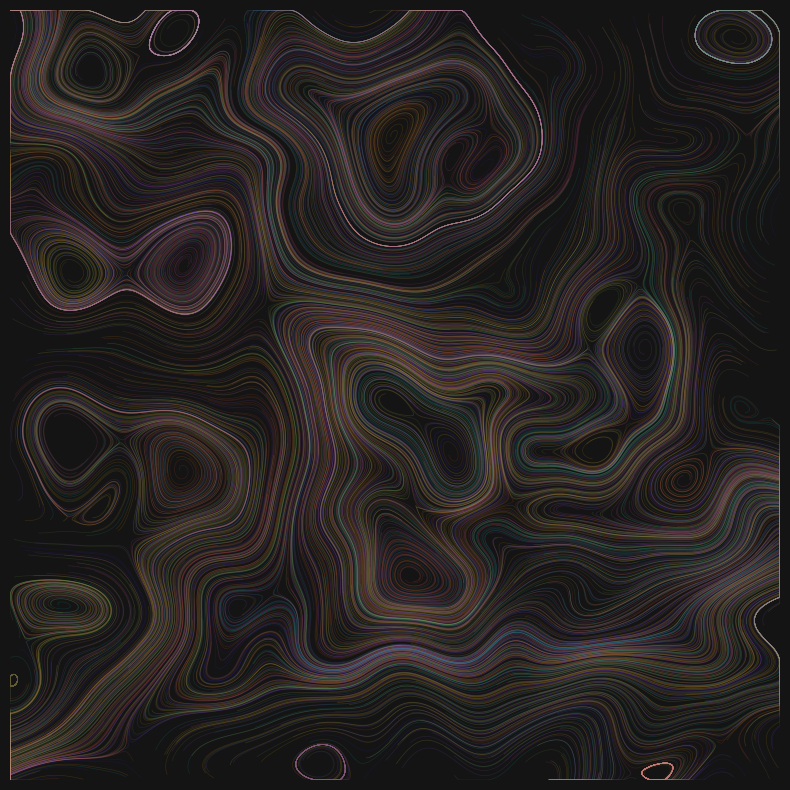

saved: assets/outputs/ch12_yourname.png


In [9]:
# save YOUR curl field: new seed, your palette, your crowd
opensimplex.seed(77)                        # change me
my_psi = fbm(axis, axis)
my_dy, my_dx = np.gradient(my_psi)
my_curl_x, my_curl_y = my_dy, -my_dx

my_rng = np.random.default_rng(24)
my_x = my_rng.random(2200) * (GRID - 1)
my_y = my_rng.random(2200) * (GRID - 1)
my_tx, my_ty = ride(my_curl_x, my_curl_y, my_x, my_y, steps=380)

my_artwork, my_ax = plt.subplots(figsize=(10, 10), facecolor="#141414")
my_trails = np.stack([my_tx.T, my_ty.T], axis=-1)
my_colors = [PALETTES["kelly"][i % 8] for i in range(2200)]
my_ax.add_collection(LineCollection(my_trails, colors=my_colors,
                                    linewidths=0.5, alpha=0.14))
my_ax.set_facecolor("#141414")
my_ax.set_xlim(0, GRID - 1)
my_ax.set_ylim(0, GRID - 1)
my_ax.set_aspect("equal")
my_ax.axis("off")
plt.show()
saved_path = save_artwork(my_artwork, "yourname", chapter=12)

## Exercises

**(a) Parameter exploration: the radius dial.** Render short loops with `noise_loop` (24 frames at `grid=120`, and a distinct `path` per radius, keep each one quick) at $R \in \{0.1, 0.3, 0.6, 1.0, 2.0\}$ and watch each for a few cycles. One sentence per radius: what is the field's *gait* (breathing, swaying, boiling, strobing)? Somewhere in that range the loop stops reading as one object changing and starts reading as different objects taking turns; note where that happens for you.

**(b) Code modification: curl of the ridges.** The potential need not be smooth fbm. Fold it, chapter 11 style ($1 - |\text{octave}|$, summed), take the curl of *that*, and trace the long exposure. Predict before you run: the ridged field's sharp crests are cliffs of the potential, and flow follows contours, so where will the skaters bunch their lanes?

<details><summary>Solution</summary>

```python
def ridged(xs, ys, octaves=4, persistence=0.5, lacunarity=2.0):
    # chapter 11's fold, condensed
    total = np.zeros((len(ys), len(xs)))
    amplitude, frequency = 1.0, 1.0
    for _ in range(octaves):
        octave = opensimplex.noise2array(xs * frequency, ys * frequency)
        total += amplitude * (1 - np.abs(octave))
        amplitude *= persistence
        frequency *= lacunarity
    return total / np.max(np.abs(total))

opensimplex.seed(11)
ridge_psi = ridged(axis, axis)
r_dy, r_dx = np.gradient(ridge_psi)
ridge_curl_x, ridge_curl_y = r_dy, -r_dx

r_rng = np.random.default_rng(9)
r_x = r_rng.random(2600) * (GRID - 1)
r_y = r_rng.random(2600) * (GRID - 1)
r_tx, r_ty = ride(ridge_curl_x, ridge_curl_y, r_x, r_y, steps=420)

fig, ax = plt.subplots(figsize=(10, 10), facecolor="#0A1220")
ax.add_collection(LineCollection(np.stack([r_tx.T, r_ty.T], axis=-1),
                                 colors="#BFE8F2", linewidths=0.4, alpha=0.15))
ax.set_facecolor("#0A1220")
ax.set_xlim(0, GRID - 1)
ax.set_ylim(0, GRID - 1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()
```

The skaters crowd into tight parallel lanes hugging both sides of every crest: a ridge in the potential is a wall of closely packed contour lines, and contour-followers must run along it, single file. Between ridges, in the smooth valleys, the lanes relax and spread. The long exposure reads as a road map of the mountain system, all switchbacks and valley roads, where the smooth potential gave rounded provinces.
</details>

**(c) Creative challenge: close every circle.** Two roads, pick one. *The looping exposure:* advect a modest crowd of particles while the field itself travels one full circle of 4D noise (recompute the curl from the current frame's potential at each step), stamp the trails onto a slowly fading canvas (chapter 19's trick, arriving early), and export the frames; if the fade has mostly forgotten frame 0 by the time $\theta$ comes home, the seam disappears. *Or the marbling clock:* take chapter 11's domain warp and drive its shove amplitude by $\sin\theta$ while $\theta$ walks the circle, so your marbled paper folds itself and unfolds, forever. Both are harder than they look, and both were state of the art on someone's web gallery in 2015; the tools are all on this page.

## Further reading

- Robert Bridson, Jim Hourihan and Marcus Nordenstam, "Curl-Noise for Procedural Fluid Flow", *ACM Transactions on Graphics* 26, no. 3 (SIGGRAPH 2007): three pages, one identity, twenty years of film smoke; the source of this chapter's quarter turn.
- The Public Domain Review's page of phenakistiscope discs (digitized by the Library of Congress): the 1830s discs spinning again as, fittingly, GIFs.
- Etienne Jacob's tutorial series on looping GIFs with 4D noise at necessarydisorder.wordpress.com: the contemporary folk canon of the technique, with variations far beyond this chapter's.
- *Texturing and Modeling: A Procedural Approach* (chapter 11's shared bookshelf) documents the higher-dimensional noise this chapter quietly relied on, in Darwyn Peachey's and David Ebert's chapters on animated textures: someone had to build a 4D noise function before anyone could walk circles through it.

## References

- <span id="ref-bridson2007"></span>Bridson, R., Hourihan, J., and Nordenstam, M. (2007). Curl-noise for procedural fluid flow. *ACM Transactions on Graphics*, 26(3), Article 46. [doi:10.1145/1276377.1276435](https://doi.org/10.1145/1276377.1276435). Source of the quarter turn and of the "gutters" quoted above.
- <span id="ref-eppink2014"></span>Eppink, J. (2014). A brief history of the GIF (so far). *Journal of Visual Culture*, 13(3), 298–306. [doi:10.1177/1470412914553365](https://doi.org/10.1177/1470412914553365). The GIF's 1987 CompuServe birth and the 1995 Netscape looping extension.
- <span id="ref-horner1834"></span>Horner, W. G. (1834). On the properties of the Dædaleum, a new instrument of optical illusion. *The London and Edinburgh Philosophical Magazine and Journal of Science*, 3rd ser., 4(19), 36–41. The disc bent into a drum, in the inventor's own words.
- <span id="ref-jacob2017"></span>Jacob, É. (2017). Drawing from noise, and then making animated loopy GIFs from there. *necessary-disorder tutorials*. [necessarydisorder.wordpress.com](https://necessarydisorder.wordpress.com/2017/11/15/drawing-from-noise-and-then-making-animated-loopy-gifs-from-there/). The 4D-noise seamless loop as the folk canon teaches it.
- <span id="ref-lincoln1867"></span>Lincoln, W. E. (1867). Toy. US Patent 64,117, assigned to Milton Bradley and Co., Springfield, Massachusetts, granted 23 April 1867. [Google Patents](https://patents.google.com/patent/US64117A/en). The zoetrope patent.
- <span id="ref-mannoni2000"></span>Mannoni, L. (2000). *The Great Art of Light and Shadow: Archaeology of the Cinema* (trans. R. Crangle). University of Exeter Press. The scholarly history of pre-cinema devices, Plateau and Stampfer included.


---
### Appendix: regenerate the showpiece

This last cell (re)creates the still at the top of the notebook: 4200 skaters, 600 steps on the chapter's curl field, glacier palette on deep water, with the loop GIF as its moving companion piece (regenerated by the loop cell above; the PNG is the artwork of record for the gallery). It runs automatically with *Restart & Run All*.

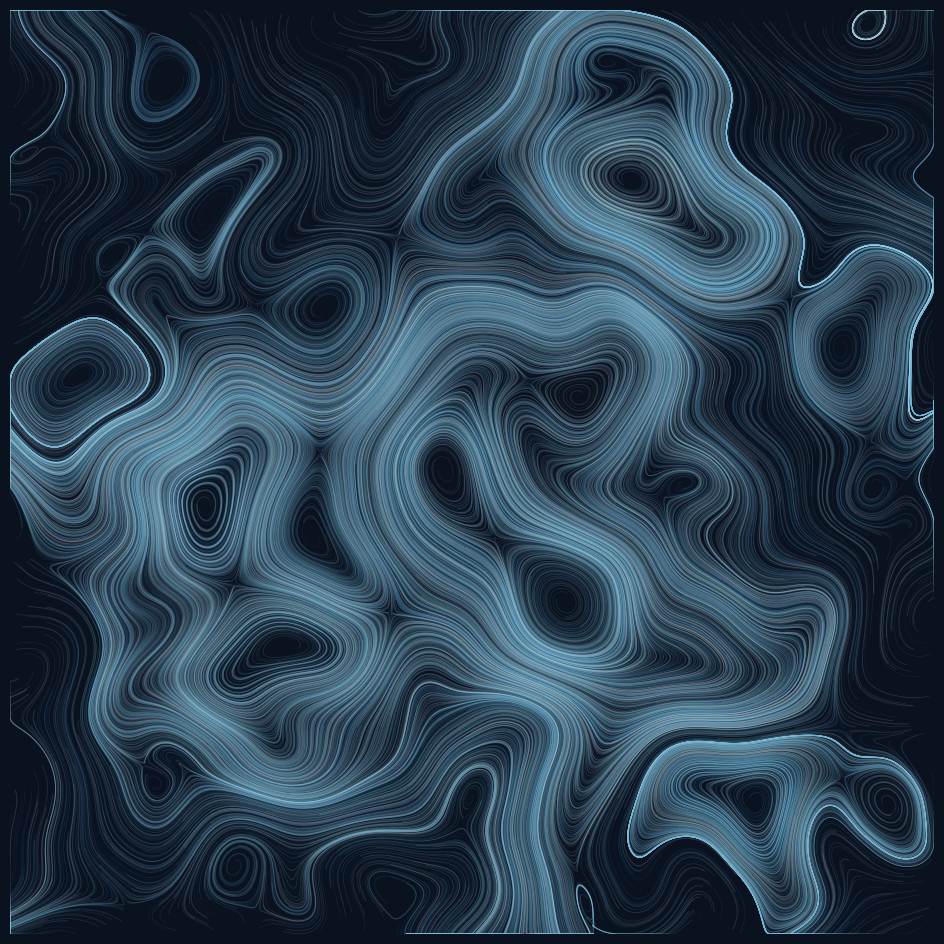

saved: assets/outputs/ch12_showpiece.png


In [10]:
# regenerate this chapter's showpiece: the sealed aquarium, long exposure
sp_rng = np.random.default_rng(9)
sp_x = sp_rng.random(4200) * (GRID - 1)
sp_y = sp_rng.random(4200) * (GRID - 1)
sp_tx, sp_ty = ride(curl_x, curl_y, sp_x, sp_y, steps=600)

showpiece, sp_ax = plt.subplots(figsize=(12, 12), facecolor="#0A1220")
sp_trails = np.stack([sp_tx.T, sp_ty.T], axis=-1)
sp_colors = [GLACIER[i % len(GLACIER)] for i in range(4200)]
sp_widths = sp_rng.uniform(0.25, 0.9, 4200)
sp_ax.add_collection(LineCollection(sp_trails, colors=sp_colors,
                                    linewidths=sp_widths, alpha=0.13))
sp_ax.set_facecolor("#0A1220")
sp_ax.set_xlim(0, GRID - 1)
sp_ax.set_ylim(0, GRID - 1)
sp_ax.set_aspect("equal")
sp_ax.axis("off")
plt.show()
saved_path = save_artwork(showpiece, "showpiece", chapter=12)